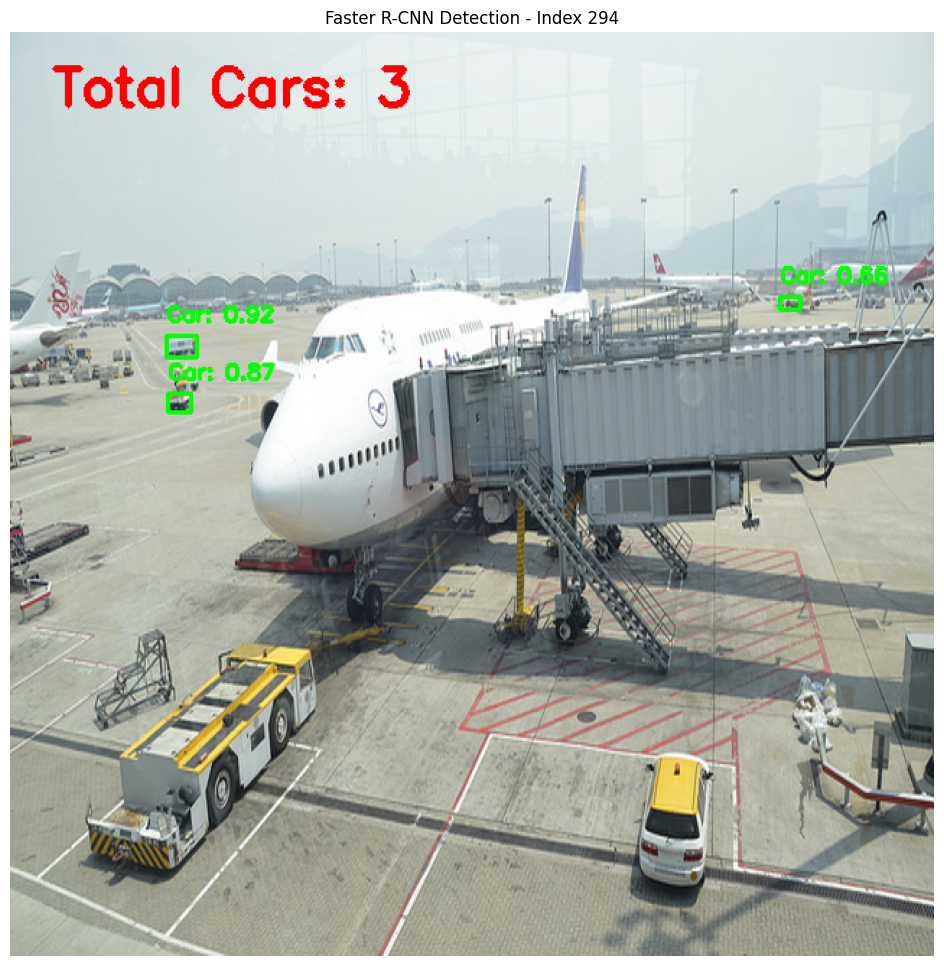

In [10]:
# @title
import random

val_dataset = CarDataset('/content/drive/MyDrive/vehicle_project/val.txt')
# --- 4. Run Inference on a Random Image ---
idx = random.randint(0, len(val_dataset)-1)
img_tensor, target = val_dataset[idx]

with torch.no_grad():
   prediction = model([img_tensor.to(device)])[0]

# Apply NMS (Cleans up overlapping boxes)
keep = torchvision.ops.nms(prediction['boxes'], prediction['scores'], 0.3)
final_pred = {
   'boxes': prediction['boxes'][keep],
   'scores': prediction['scores'][keep],
   'labels': prediction['labels'][keep]
}

# Plot with the new Count Stamp
plt.figure(figsize=(12, 12))
# Note: Ensure the threshold here matches the one used for counting
result_img = plot_prediction(img_tensor, final_pred, threshold=0.5)
plt.imshow(result_img)
plt.axis('off')
plt.title(f"Faster R-CNN Detection - Index {idx}")
plt.show()



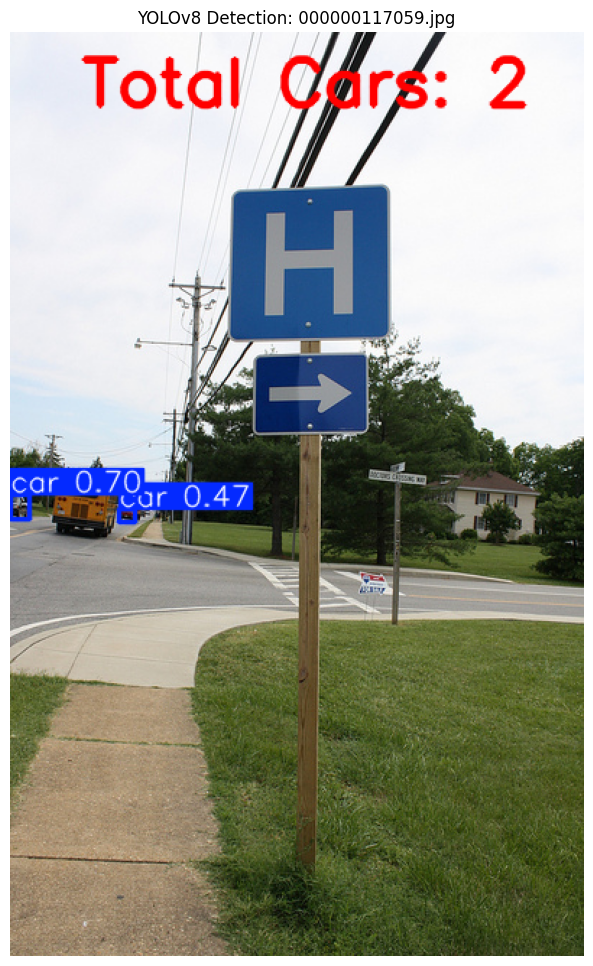

In [14]:
# @title
# 4. Display the Result
for r in results:
   # 1. Get the image with boxes drawn (returns BGR numpy array)
   im_array = r.plot()

   # 2. Get the count of detections
   # r.boxes contains all detected bounding boxes
   car_count = len(r.boxes)

   # 3. Add the Count Stamp using OpenCV
   # use a high thickness and scale so it's readable
   text = f"Total Cars: {car_count}"
   cv2.putText(
       im_array,
       text,
       (50, 50),                 # Position (X, Y)
       cv2.FONT_HERSHEY_SIMPLEX,
       1.5,                      # Font scale
       (0, 0, 255),              # Red color in BGR
       3,                        # Thickness
       cv2.LINE_AA
   )

   # 4. Convert BGR (OpenCV) to RGB (Matplotlib)
   im_rgb = cv2.cvtColor(im_array, cv2.COLOR_BGR2RGB)

   plt.figure(figsize=(12, 12))
   plt.imshow(im_rgb)
   plt.axis('off')
   plt.title(f"YOLOv8 Detection: {Path(random_img_path).name}")
   plt.show()



In [12]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 70.5 MB/s eta 0:00:00


In [ ]:
# @title 1. Setup and Data Download (Training Set - HIGH VOLUME)
import os
import requests
import zipfile
import shutil
import numpy as np
from pycocotools.coco import COCO
from pathlib import Path
from tqdm.notebook import tqdm
import cv2
import random

DOWNLOAD_LIMIT = 5000
# ---------------------

# Define relevant COCO classes
TARGET_CLASSES = ['car']

# Create directory structure
base_dir = Path('vehicle_project')
images_dir = base_dir / 'images'
labels_dir = base_dir / 'labels'
coco_root = base_dir / 'coco_annotations'

for d in [images_dir, labels_dir, coco_root]:
    d.mkdir(parents=True, exist_ok=True)

# Download COCO 2017 Train/Val Annotations
ann_url = "http://images.cocodataset.org/annotations/annotations_trainval2017.zip"
ann_zip = coco_root / "annotations.zip"

if not (coco_root / 'annotations').exists():
    print("Downloading annotations (this may take a moment)...")
    r = requests.get(ann_url)
    with open(ann_zip, 'wb') as f:
        f.write(r.content)
    with zipfile.ZipFile(ann_zip, 'r') as zip_ref:
        zip_ref.extractall(coco_root)

# Initialize COCO API with TRAINING data (instances_train2017.json)
# This is the key change from your previous code
train_json_path = coco_root / 'annotations/instances_train2017.json'
if not train_json_path.exists():
    # Fallback if the zip extraction folder structure varies
    train_json_path = coco_root / 'instances_train2017.json'

print(f"Loading COCO API from {train_json_path}...")
coco = COCO(train_json_path)

# Get Category IDs
cat_ids = coco.getCatIds(catNms=TARGET_CLASSES)
print(f"Target Category IDs: {cat_ids}")

# Get all Image IDs containing ANY of our target classes
img_ids = set()
for cat_id in cat_ids:
    img_ids.update(coco.getImgIds(catIds=[cat_id]))
img_ids = list(img_ids)
print(f"Found {len(img_ids)} total images available in Training set.")

# Shuffle and Limit
random.shuffle(img_ids)
if DOWNLOAD_LIMIT and DOWNLOAD_LIMIT < len(img_ids):
    download_ids = img_ids[:DOWNLOAD_LIMIT]
    print(f"Limiting download to random {len(download_ids)} images for Colab safety.")
else:
    download_ids = img_ids
    print(f"Preparing to download ALL {len(download_ids)} images.")

# Function to convert COCO bbox to YOLO format
def coco_to_yolo(bbox, img_w, img_h):
    x, y, w, h = bbox
    x_center = (x + w / 2) / img_w
    y_center = (y + h / 2) / img_h
    width = w / img_w
    height = h / img_h
    return x_center, y_center, width, height

# Download Images and Generate Labels
print("Downloading images and generating labels...")
count = 0
for img_id in tqdm(download_ids):
    img_info = coco.loadImgs(img_id)[0]
    img_name = img_info['file_name']
    image_path = images_dir / img_name
    label_path = labels_dir / img_name.replace('.jpg', '.txt')

    # Skip if already downloaded
    if image_path.exists() and label_path.exists():
        count += 1
        continue

    # Download Image
    img_url = img_info['coco_url']
    try:
        img_data = requests.get(img_url, timeout=10).content
        with open(image_path, 'wb') as handler:
            handler.write(img_data)
    except Exception as e:
        print(f"Failed to download {img_name}: {e}")
        continue

    # Get Annotations
    ann_ids = coco.getAnnIds(imgIds=img_id, catIds=cat_ids, iscrowd=None)
    anns = coco.loadAnns(ann_ids)

    # Write YOLO label file
    with open(label_path, 'w') as f:
        for ann in anns:
            class_idx = cat_ids.index(ann['category_id'])
            xc, yc, w, h = coco_to_yolo(ann['bbox'], img_info['width'], img_info['height'])
            f.write(f"{class_idx} {xc} {yc} {w} {h}\n")
    count += 1

print(f"Data preparation complete. {count} images ready for training.")

Loading COCO API from vehicle_project/coco_annotations/annotations/instances_train2017.json...
loading annotations into memory...
Done (t=12.36s)
creating index...
index created!
Target Category IDs: [3]
Found 12251 total images available in Training set.
Limiting download to random 5000 images for Colab safety.


  0%|          | 0/5000 [00:00<?, ?it/s]

Data preparation complete. 5000 images ready for training.


In [ ]:
# @title 2. Data Splitting (Train/Val Split)
import os
import random
from pathlib import Path

# Configuration
base_dir = Path('/content/drive/MyDrive/vehicle_project')
images_dir = base_dir / 'images'
labels_dir = base_dir / 'labels'

# 1. Get all image files that have a corresponding label
all_images = list(images_dir.glob('*.jpg'))
valid_pairs = []

print(f"Checking {len(all_images)} images for matching labels...")
for img_path in all_images:
    label_path = labels_dir / img_path.name.replace('.jpg', '.txt')
    if label_path.exists():
        valid_pairs.append(img_path)

print(f"✅ Found {len(valid_pairs)} valid image-label pairs.")

# 2. Shuffle and Split (80% Train, 20% Validation)
random.seed(42) # For reproducibility
random.shuffle(valid_pairs)

split_idx = int(len(valid_pairs) * 0.8)
train_files = valid_pairs[:split_idx]
val_files = valid_pairs[split_idx:]

# 3. Create the manifest .txt files
# YOLO needs these files to know which images belong to which set
with open(base_dir / 'train.txt', 'w') as f:
    for path in train_files:
        f.write(str(path.absolute()) + '\n')

with open(base_dir / 'val.txt', 'w') as f:
    for path in val_files:
        f.write(str(path.absolute()) + '\n')

print(f"📊 Dataset Split Complete:")
print(f"   - Training images: {len(train_files)}")
print(f"   - Validation images: {len(val_files)}")

Checking 2443 images for matching labels...
✅ Found 2443 valid image-label pairs.
📊 Dataset Split Complete:
   - Training images: 1954
   - Validation images: 489


In [ ]:
import yaml
from pathlib import Path

base_dir = Path("/content/drive/MyDrive/vehicle_project")

yaml_content = {
    'path': str(base_dir.absolute()),
    'train': 'train.txt',
    'val': 'val.txt',
    'nc': 1,
    'names': ['car']
}

with open(base_dir / 'data.yaml', 'w') as f:
    yaml.dump(yaml_content, f)


In [ ]:
# @title 3. Train YOLOv8m (Optimized for Car Detection)
from ultralytics import YOLO
import torch

# 1. Load the Medium model weights
model2 = YOLO('yolov8m.pt')

print("🚀 Starting Optimized Training on 5,000 images...")

# 2. Execute Training
results2 = model2.train(
    data='/content/drive/MyDrive/vehicle_project/data.yaml',
    epochs=50,             # High epochs; early stopping will kick in if it plateaus
    imgsz=640,              # Standard high-res input
    batch=16,               # Safe batch size for Medium model on Colab GPUs
    device=0,               # Use CUDA (GPU)
    project='vehicle_project',
    name='yolov8m_car_optimized',

    # --- Optimization Settings ---
    optimizer='Adam',      # Superior convergence for custom datasets
    lr0=0.0001,              # Balanced starting LR for AdamW
    cos_lr=True,            # Smoothly decays LR to reach highest accuracy

    # --- Regularization (Preventing Overfitting) ---
    weight_decay=0.0005,     # Penalizes overly complex weights
    dropout=0.1,            # Randomly ignores neurons to force robustness
    label_smoothing=0.1,    # Prevents over-confidence, improving generalization
    patience=10,            # Stop if no improvement for 15 epochs
    box = 5,
    iou = 0.7,
    dfl = 1.2,

    # --- Data Augmentation ---
    augment=True,           # Enables Mosaic, Mixup, and Flips
    mosaic=1,             # High mosaic helps detect cars at different scales

)

print("✅ Training Complete! Results saved in vehicle_project/yolov8m_car_optimized")

🚀 Starting Optimized Training on 5,000 images...
WARNING ⚠️ 'label_smoothing' is deprecated and will be removed in the future.
Ultralytics 8.4.7 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (NVIDIA L4, 22693MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/drive/MyDrive/vehicle_project/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.2, dnn=False, dropout=0.1, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1, multi_scale=

In [ ]:
# @title Evaluate the Trained Model
# Load your best weights from the run above
model_eval = YOLO('/content/drive/MyDrive/detect/vehicle_project/yolov8m_car_optimized/weights/best.pt')

# Run validation on the 'val' set defined in your data.yaml
metrics = model_eval.val()

print(f"Final mAP@50: {metrics.box.map50:.4f}")
print(f"Final mAP@50-95: {metrics.box.map:.4f}")
print(f"Precision: {metrics.box.mp:.4f}")
print(f"Recall: {metrics.box.mr:.4f}")

Ultralytics 8.4.7 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (NVIDIA L4, 22693MiB)
Model summary (fused): 93 layers, 25,840,339 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.2±0.0 ms, read: 124.8±8.8 MB/s, size: 186.6 KB)
val: Scanning /content/drive/MyDrive/vehicle_project/labels.cache... 489 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 489/489 136.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 31/31 5.5it/s 5.6s
                   all        489       1727      0.784      0.651      0.734      0.491
Speed: 0.7ms preprocess, 6.4ms inference, 0.0ms loss, 1.2ms postprocess per image
Results saved to /content/runs/detect/val2
Final mAP@50: 0.7343
Final mAP@50-95: 0.4910
Precision: 0.7843
Recall: 0.6514


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


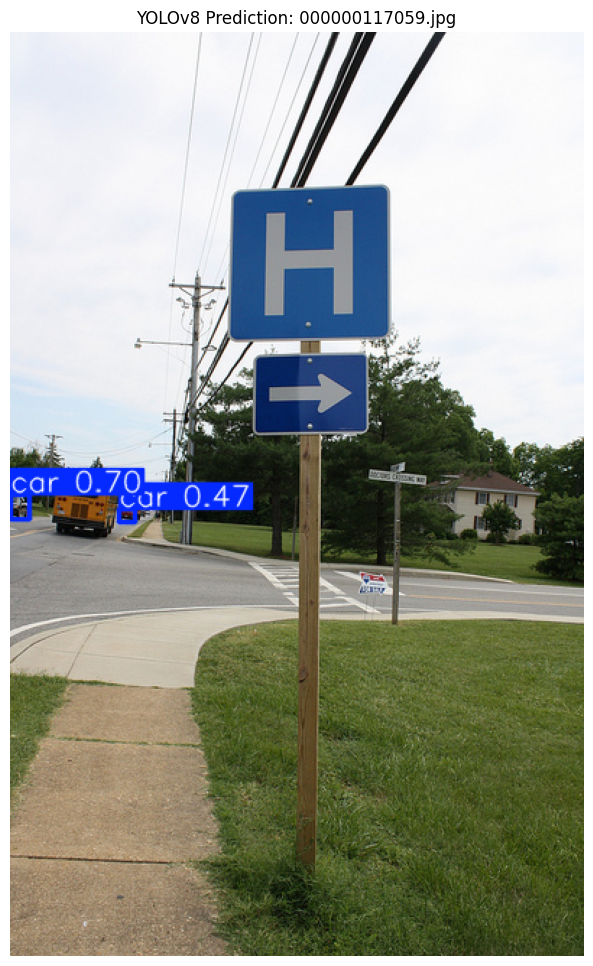

In [13]:
# @title 7. Visualize YOLOv8 Prediction (The "Eye Test")
from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2
import random
import os
from pathlib import Path

# 1. Load your best trained model
# Make sure this path matches your best run (e.g., optimized4)
model_path = '/content/drive/MyDrive/detect/vehicle_project/yolov8m_car_optimized/weights/best.pt'
model = YOLO(model_path)

# 2. Pick a random image from the validation set
# We read the val.txt file to get valid paths
with open('/content/drive/MyDrive/vehicle_project/val.txt', 'r') as f:
    val_images = [line.strip() for line in f.readlines()]

random_img_path = random.choice(val_images)

# 3. Run Inference
# conf=0.25: Only show boxes with >25% confidence (Filters weak noise)
# iou=0.45:  NMS threshold (Merges overlapping boxes)
results = model.predict(
    source=random_img_path,
    conf=0.25,
    iou=0.45,
    save=False,
    verbose=False
)

# 4. Display the Result
for r in results:
    # r.plot() returns a BGR numpy array with boxes drawn
    im_array = r.plot()

    # Convert BGR (OpenCV) to RGB (Matplotlib)
    im_rgb = cv2.cvtColor(im_array, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(12, 12))
    plt.imshow(im_rgb)
    plt.axis('off')
    plt.title(f"YOLOv8 Prediction: {Path(random_img_path).name}")
    plt.show()

In [ ]:
# @title 1. Generate YOLOv8 Video
from ultralytics import YOLO
from IPython.display import FileLink

# 2. Define source video path
# Upload a video to your Colab 'vehicle_project' folder and change this name!
source_video = '/content/drive/MyDrive/test_video.mp4'

# 3. Run Inference with "save=True"
# This automatically creates a labeled video file
results = model.predict(
    source=source_video,
    save=True,
    conf=0.25,        # Confidence threshold
    iou=0.45,         # NMS threshold
    project='vehicle_project',
    name='yolo_video_output'
)

print("✅ YOLO Video Saved!")
print(f"📁 Path: {results[0].save_dir}")

WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

Results saved to /content/runs/detect/vehicle_project/yolo_video_output
✅ YOLO Video Saved!
📁 Path: /content/runs/detect/vehicle_project/yolo_video_output


In [ ]:
# @title 8b. Measure YOLOv8 Inference Speed (FPS)
from ultralytics import YOLO
import torch
import time


# 2. Prepare Dummy Input (Standard 640x640)
# YOLOv8 handles the device transfer internally, but we pass a clean image
dummy_img = '/content/drive/MyDrive/vehicle_project/val.txt'
# We'll actually just use a random array to simulate a raw frame for pure model speed
import numpy as np
dummy_frame = np.random.randint(0, 255, (640, 640, 3), dtype='uint8')

print(f"⏱️ Measuring Speed for YOLOv8m...")

# 3. Warm-up (Crucial)
print("   Warming up GPU...")
for _ in range(20):
    _ = model.predict(dummy_frame, verbose=False, half=True) # half=True uses FP16 (standard for deployment)

# 4. Timing Loop
num_runs = 100
start_time = time.time()

for _ in range(num_runs):
    # We use half=True because that's how you would deploy it in real-time
    # verbose=False stops it from printing "Image 1/1..." every time
    _ = model.predict(dummy_frame, verbose=False, half=True)

end_time = time.time()

# 5. Calculate Metrics
total_time = end_time - start_time
avg_time_sec = total_time / num_runs
avg_time_ms = avg_time_sec * 1000
fps = 1 / avg_time_sec

print("\n" + "="*30)
print("🚀 Speed Test Results (YOLOv8m)")
print("="*30)
print(f"Average Inference Time: {avg_time_ms:.2f} ms")
print(f"Frames Per Second (FPS): {fps:.2f}")
print("="*30)

⏱️ Measuring Speed for YOLOv8m...
   Warming up GPU...

🚀 Speed Test Results (YOLOv8m)
Average Inference Time: 10.57 ms
Frames Per Second (FPS): 94.61


In [ ]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 54.9 MB/s eta 0:00:00


In [ ]:
# @title 5. Train Faster R-CNN (The Comparison Model)
import torch
import torchvision
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torch.utils.data import DataLoader, Dataset
from PIL import Image
import os
from tqdm.notebook import tqdm

# --- 1. Define the Custom Dataset (YOLO Format -> COCO Format) ---
class CarDataset(Dataset):
    def __init__(self, manifest_file, width=640, height=640):
        with open(manifest_file, 'r') as f:
            self.img_paths = [line.strip() for line in f.readlines()]
        self.w = width
        self.h = height

    def __getitem__(self, idx):
        # Load Image
        img_path = self.img_paths[idx]
        img = Image.open(img_path).convert("RGB")
        img = img.resize((self.w, self.h))

        # Convert to Tensor (0-1 range)
        img_tensor = torchvision.transforms.functional.to_tensor(img)

        # Load Labels
        label_path = img_path.replace('images', 'labels').replace('.jpg', '.txt')
        boxes = []
        labels = []

        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                lines = f.readlines()
                for line in lines:
                    # Parse YOLO: class x_center y_center w h
                    parts = list(map(float, line.split()))
                    # We assume class is always 0 (car), so we skip parts[0]
                    # Faster R-CNN needs [x_min, y_min, x_max, y_max] in pixels
                    xc, yc, bw, bh = parts[1], parts[2], parts[3], parts[4]

                    xmin = (xc - bw/2) * self.w
                    xmax = (xc + bw/2) * self.w
                    ymin = (yc - bh/2) * self.h
                    ymax = (yc + bh/2) * self.h

                    boxes.append([xmin, ymin, xmax, ymax])
                    labels.append(1) # Class 1 = Car (0 is background in R-CNN)

        # Convert to Tensors
        if len(boxes) > 0:
            boxes = torch.as_tensor(boxes, dtype=torch.float32)
            labels = torch.as_tensor(labels, dtype=torch.int64)
            area = (boxes[:, 3] - boxes[:, 1]) * (boxes[:, 2] - boxes[:, 0])
            iscrowd = torch.zeros((len(boxes),), dtype=torch.int64)
        else:
            # Handle empty images (Background)
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)
            area = torch.zeros((0,), dtype=torch.float32)
            iscrowd = torch.zeros((0,), dtype=torch.int64)
x
        target = {}
        target["boxes"] = boxes
        target["labels"] = labels
        target["image_id"] = torch.tensor([idx])
        target["area"] = area
        target["iscrowd"] = iscrowd

        return img_tensor, target

    def __len__(self):
        return len(self.img_paths)

# --- 2. Setup Data Loaders ---
# Use the same splits as YOLO
train_dataset = CarDataset('/content/drive/MyDrive/vehicle_project/train.txt')
val_dataset = CarDataset('/content/drive/MyDrive/vehicle_project/val.txt')

# Collator handles batches of different sized boxes
def collate_fn(batch):
    return tuple(zip(*batch))

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, collate_fn=collate_fn)

# --- 3. Setup Model ---
def get_model():
    # Load Pretrained ResNet50
    model = fasterrcnn_resnet50_fpn(weights="DEFAULT")

    # Replace Head for 2 classes (0: Background, 1: Car)
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, 2)
    return model

device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
model = get_model().to(device)

import torch
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from collections import defaultdict

# --- Helper Function for Evaluation ---
def evaluate(model, data_loader, device):
    model.eval()
    metric = MeanAveragePrecision(iou_type="bbox")

    # We use torch.no_grad() because we don't need gradients for evaluation
    with torch.no_grad():
        for images, targets in tqdm(data_loader, desc="Evaluating", leave=False):
            images = list(img.to(device) for img in images)

            # Move targets to device
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

            # Get Predictions
            outputs = model(images)

            # Update Metric (CPU is preferred for metric accumulation to save GPU VRAM)
            metric.update(outputs, targets)

    # Compute the results
    result = metric.compute()
    return result

# --- 4. Training Loop with mAP and Detailed Loss ---
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

print(f"🚀 Starting Faster R-CNN Training on {device}...")
num_epochs = 10

# Store history for plotting later if needed
history = {
    "map50": [],
    "total_loss": []
}

for epoch in range(num_epochs):
    model.train()

    # Track individual losses
    loss_tracker = defaultdict(float)
    total_batches = len(train_loader)

    prog_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]")

    for images, targets in prog_bar:
        images = list(image.to(device) for image in images)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)

        # Sum up all losses for backprop
        losses = sum(loss for loss in loss_dict.values())

        # Accumulate specific losses for logging (detach to prevent graph buildup)
        for k, v in loss_dict.items():
            loss_tracker[k] += v.item()
        loss_tracker["total_loss"] += losses.item()

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        # Update progress bar with current total loss
        prog_bar.set_postfix(loss=losses.item())

    lr_scheduler.step()

    # --- Calculate Average Losses for the Epoch ---
    avg_losses = {k: v / total_batches for k, v in loss_tracker.items()}
    history["total_loss"].append(avg_losses["total_loss"])

    # --- Run Validation (Calculate mAP) ---
    print(f"Stats: Loss: {avg_losses['total_loss']:.4f} | RPN Box: {avg_losses['loss_rpn_box_reg']:.4f} | Cls: {avg_losses['loss_classifier']:.4f}")

    # Run evaluation on validation set
    val_metrics = evaluate(model, val_loader, device)
    map50 = val_metrics['map_50'].item()
    map_val = val_metrics['map'].item() # mAP 0.5:0.95

    history["map50"].append(map50)

    print(f"✅ Epoch {epoch+1} Results:")
    print(f"   • mAP@50: {map50:.4f}")
    print(f"   • mAP (0.5:0.95): {map_val:.4f}")
    print("-" * 40)

print("🏆 Training Complete.")
# Save model
torch.save(model.state_dict(), '/content/runs/faster_rcnn_car_final.pth')

🚀 Starting Faster R-CNN Training on cuda...


Epoch 1/10 [Train]:   0%|          | 0/245 [00:00<?, ?it/s]

In [5]:
import torch
import torchvision
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torch.utils.data import DataLoader, Dataset
from PIL import Image
import os
from tqdm.notebook import tqdm

# --- 1. Define the Custom Dataset (YOLO Format -> COCO Format) ---
class CarDataset(Dataset):
    def __init__(self, manifest_file, width=640, height=640):
        with open(manifest_file, 'r') as f:
            self.img_paths = [line.strip() for line in f.readlines()]
        self.w = width
        self.h = height

    def __getitem__(self, idx):
        # Load Image
        img_path = self.img_paths[idx]
        img = Image.open(img_path).convert("RGB")
        img = img.resize((self.w, self.h))

        # Convert to Tensor (0-1 range)
        img_tensor = torchvision.transforms.functional.to_tensor(img)

        # Load Labels
        label_path = img_path.replace('images', 'labels').replace('.jpg', '.txt')
        boxes = []
        labels = []

        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                lines = f.readlines()
                for line in lines:
                    # Parse YOLO: class x_center y_center w h
                    parts = list(map(float, line.split()))
                    # We assume class is always 0 (car), so we skip parts[0]
                    # Faster R-CNN needs [x_min, y_min, x_max, y_max] in pixels
                    xc, yc, bw, bh = parts[1], parts[2], parts[3], parts[4]

                    xmin = (xc - bw/2) * self.w
                    xmax = (xc + bw/2) * self.w
                    ymin = (yc - bh/2) * self.h
                    ymax = (yc + bh/2) * self.h

                    boxes.append([xmin, ymin, xmax, ymax])
                    labels.append(1) # Class 1 = Car (0 is background in R-CNN)

        # Convert to Tensors
        if len(boxes) > 0:
            boxes = torch.as_tensor(boxes, dtype=torch.float32)
            labels = torch.as_tensor(labels, dtype=torch.int64)
            area = (boxes[:, 3] - boxes[:, 1]) * (boxes[:, 2] - boxes[:, 0])
            iscrowd = torch.zeros((len(boxes),), dtype=torch.int64)
        else:
            # Handle empty images (Background)
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)
            area = torch.zeros((0,), dtype=torch.float32)
            iscrowd = torch.zeros((0,), dtype=torch.int64)

        target = {}
        target["boxes"] = boxes
        target["labels"] = labels
        target["image_id"] = torch.tensor([idx])
        target["area"] = area
        target["iscrowd"] = iscrowd

        return img_tensor, target

    def __len__(self):
        return len(self.img_paths)

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 226MB/s]


Showing prediction for image index: 82


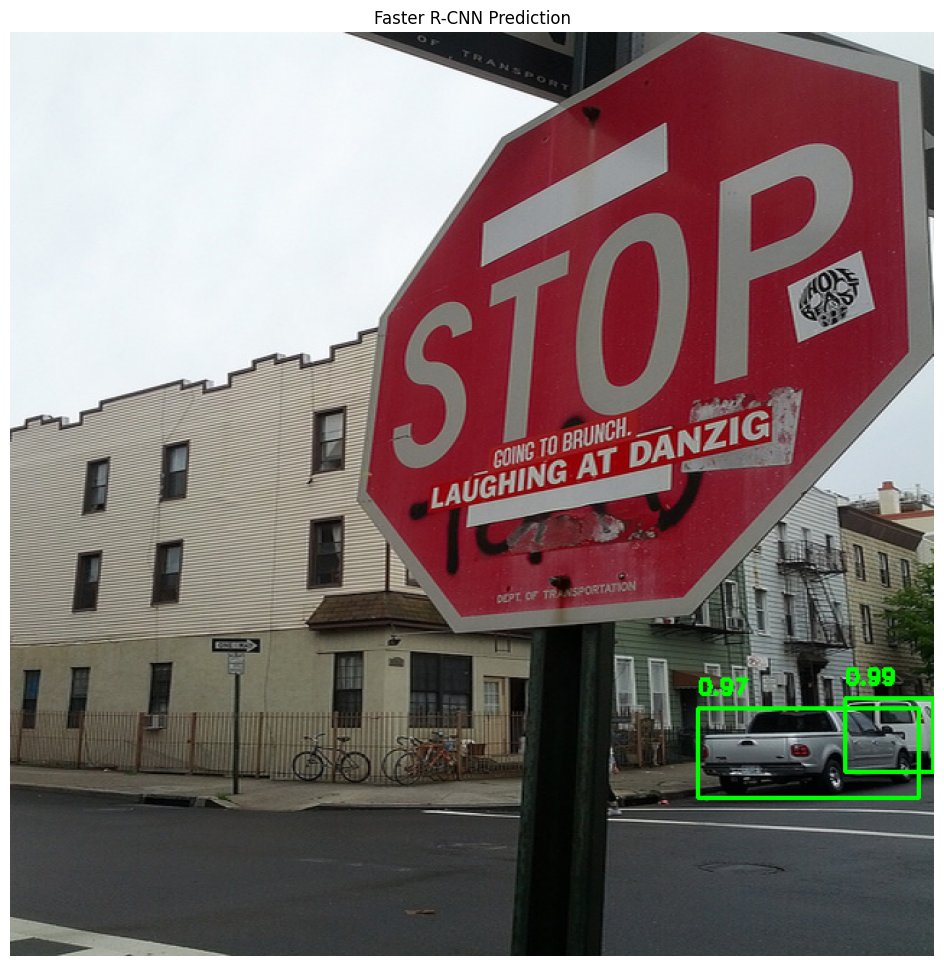

In [7]:
# @title 7. Visualize Faster R-CNN Prediction (Fixed)
import torch
import torchvision
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
import matplotlib.pyplot as plt
import cv2
import numpy as np

val_dataset = CarDataset('/content/drive/MyDrive/vehicle_project/val.txt')
# --- 1. Re-Define the Model Architecture ---
# You must use the exact same structure as training
def get_model():
    model = fasterrcnn_resnet50_fpn(weights=None) # No need to download pretrained weights again
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, 2) # 2 classes: Background + Car
    return model

# --- 2. Load the Weights ---
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
model = get_model()

# Load the .pth file properly
model_path = '/content/drive/MyDrive/faster_rcnn_car.pth'
model.load_state_dict(torch.load(model_path, map_location=device))
model.to(device)
model.eval() # Set to evaluation mode

# --- 3. Visualization Logic ---
def plot_prediction(img_tensor, prediction, threshold=0.5):
    # Convert Tensor to Numpy Image
    img = img_tensor.permute(1, 2, 0).cpu().numpy()
    img = np.ascontiguousarray(img)
    img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)

    # Filter by Confidence Score
    scores = prediction['scores'].cpu().numpy()
    boxes = prediction['boxes'].cpu().numpy().astype(int)

    keep = scores > threshold
    filtered_boxes = boxes[keep]
    filtered_scores = scores[keep]

    # Draw Boxes
    for box, score in zip(filtered_boxes, filtered_scores):
        cv2.rectangle(img, (box[0], box[1]), (box[2], box[3]), (0, 255, 0), 2)
        cv2.putText(img, f"{score:.2f}", (box[0], box[1]-10),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# --- 4. Run Inference on a Random Image ---
# Ensure val_dataset is defined from previous steps
import random
idx = random.randint(0, len(val_dataset)-1)
img_tensor, target = val_dataset[idx]

with torch.no_grad():
    # Faster R-CNN expects a list of tensors
    prediction = model([img_tensor.to(device)])[0]

# Apply NMS (Optional cleanup)
keep = torchvision.ops.nms(prediction['boxes'], prediction['scores'], 0.3)
final_pred = {
    'boxes': prediction['boxes'][keep],
    'scores': prediction['scores'][keep],
    'labels': prediction['labels'][keep]
}

# Plot
print(f"Showing prediction for image index: {idx}")
plt.figure(figsize=(12, 12))
plt.imshow(plot_prediction(img_tensor, final_pred, threshold=0.5))
plt.axis('off')
plt.title("Faster R-CNN Prediction")
plt.show()

In [8]:
def plot_prediction(img_tensor, prediction, threshold=0.5):
   # Convert Tensor to Numpy Image
   img = img_tensor.permute(1, 2, 0).cpu().numpy()
   img = np.ascontiguousarray(img)
   # img is already in 0-1 range from ToTensor, so scale it to 255 for OpenCV
   img = (img * 255).astype(np.uint8)
   img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)

   # Filter by Confidence Score
   scores = prediction['scores'].cpu().numpy()
   boxes = prediction['boxes'].cpu().numpy().astype(int)

   keep = scores > threshold
   filtered_boxes = boxes[keep]
   filtered_scores = scores[keep]

   # --- NEW: Get the count ---
   car_count = len(filtered_boxes)

   # Draw Boxes
   for box, score in zip(filtered_boxes, filtered_scores):
       cv2.rectangle(img, (box[0], box[1]), (box[2], box[3]), (0, 255, 0), 2)
       cv2.putText(img, f"Car: {score:.2f}", (box[0], box[1]-10),
                  cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

   # --- NEW: Add the Count Stamp ---
   # Putting the text at (50, 50).
   # Parameters: Image, Text, Position, Font, Scale, Color (BGR), Thickness
   cv2.putText(img, f"Total Cars: {car_count}", (30, 50),
               cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0, 0, 255), 3)

   return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)



In [ ]:
# @title 8. Measure Inference Speed (FPS)
import time
import torch
import numpy as np

# Ensure model is in Eval mode
model.eval()
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
model.to(device)

# 1. Prepare a dummy input (Standard 640x640 image)
dummy_input = torch.rand(1, 3, 640, 640).to(device)

print(f"⏱️ Measuring Speed on {torch.cuda.get_device_name(0)}...")

# 2. Warm-up the GPU (Crucial for accurate timing)
# The first few runs are always slow due to initialization
print("   Warming up GPU...")
with torch.no_grad():
    for _ in range(20):
        _ = model(dummy_input)

# 3. Timing Loop
num_runs = 100
start_time = time.time()

with torch.no_grad():
    for _ in range(num_runs):
        _ = model(dummy_input)
        torch.cuda.synchronize() # Wait for GPU to finish completely

end_time = time.time()

# 4. Calculate Metrics
total_time = end_time - start_time
avg_time_sec = total_time / num_runs
avg_time_ms = avg_time_sec * 1000
fps = 1 / avg_time_sec

print("\n" + "="*30)
print("🚀 Speed Test Results (Faster R-CNN)")
print("="*30)
print(f"Average Inference Time: {avg_time_ms:.2f} ms")
print(f"Frames Per Second (FPS): {fps:.2f}")
print("="*30)

⏱️ Measuring Speed on NVIDIA L4...
   Warming up GPU...

🚀 Speed Test Results (Faster R-CNN)
Average Inference Time: 34.11 ms
Frames Per Second (FPS): 29.32


In [ ]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 23.9 MB/s eta 0:00:00


In [ ]:
!nvidia-smi

In [ ]:
!nvidia-smi